- EX2.7 (3 points) Integrate the Lotka–Volterra equations or predator-prey equation, (you can find more info about these equations [here](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations)).
     - Solve the Lotka–Volterra equations considering the following parameters: $a = 1.1$, $b = 0.4$, $c = 0.1$, $d = 0.4$. 
     - Consider the initial conditions $x(t=0) = 10$ and $y(t=0) = 5$

Lotka–Volterra equations:
$\begin{array}{@{}l@{}}
    \frac{\textrm{d}x}{\textrm{d}t}= ax -bxy\\
    \frac{\textrm{d}y}{\textrm{d}t}= cxy - dy
\end{array}$ 

where $x$ is the number of prey, $y$ is the number of predator, $t$ is time and the rest parameters are positive real numbers.

Solution:

<img src="figs/EX4B.png" alt="image" width="500" height="auto">


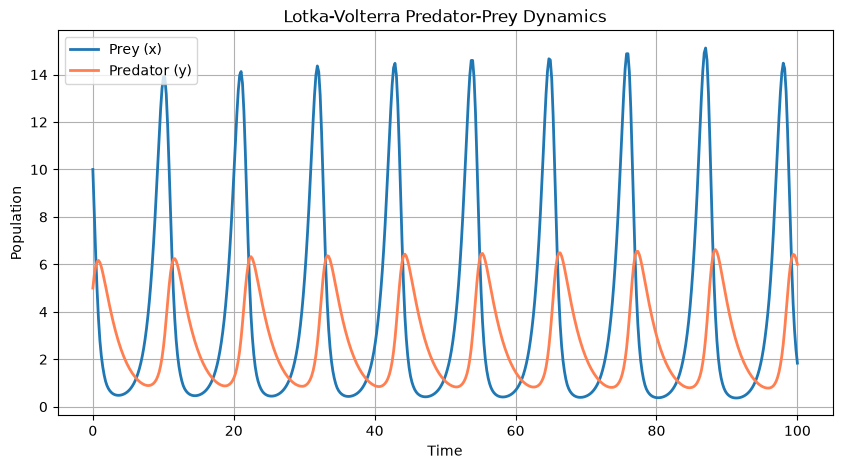

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

"""
Solve and plot the Lotka-Volterra predator-prey model using a system of
ordinary differential equations.

Inputs:
    a: Prey growth rate.
    b: Predation rate coefficient.
    c: Predator reproduction rate.
    d: Predator mortality rate.
    initial_conditions: Initial populations of prey and predators.
    t_start: Initial simulation time.
    t_end: Final simulation time.

Output:
    A plot showing the evolution of the prey and predator populations
    over time.
"""

# Define the system parameters
a = 1.1
b = 0.4
c = 0.1
d = 0.4

# Define the Lotka-Volterra system of differential equations
def lotka_volterra(t, z):
    """
    Compute the derivatives of the Lotka-Volterra predator-prey model.

    Inputs:
        t: Time.
        z: List containing the prey and predator populations.

    Output:
        List containing the time derivatives of the prey and predator
        populations.
    """
    x, y = z

    # Rate of change of the prey population
    dxdt = a * x - b * x * y

    # Rate of change of the predator population
    dydt = c * x * y - d * y

    return [dxdt, dydt]

# Define the initial conditions and time interval
initial_conditions = [10.0, 5.0]  # x(0) = 10 (prey), y(0) = 5 (predators)
t_start = 0
t_end = 100

# Define the time points where the solution will be evaluated
t_eval = np.linspace(t_start, t_end, 500)

# Solve the system of ordinary differential equations
solution = solve_ivp(
    lotka_volterra,
    [t_start, t_end],
    initial_conditions,
    t_eval=t_eval
)

# Create the figure
plt.figure(figsize=(10, 5))

# Plot the prey population
plt.plot(solution.t,
         solution.y[0],
         label='Prey (x)',
         color='tab:blue',
         lw=2)

# Plot the predator population
plt.plot(solution.t,
         solution.y[1],
         label='Predator (y)',
         color='coral',
         lw=2)

# Add title and axis labels
plt.title('Lotka-Volterra Predator-Prey Dynamics')
plt.xlabel('Time')
plt.ylabel('Population')

# Display the legend
plt.legend()

# Add a grid
plt.grid(True)

# Display the figure
plt.show()